In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as clr
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import matplotlib as mpl
import itertools as it
import argparse as ap
import statannot
from statannotations.Annotator import Annotator
%cd /groups/pavri/bioinfo/max/TriC/contactBarplots

/groups/pavri/bioinfo/max/TriC/contactBarplots


In [3]:
%run contactBarplots_functions.py -i '../resource/sampleinfo_TriC20.tsv' -r '../resource/regions_of_interest_Ramos.tsv' \
	-r1 'start-cG1' '3RRCBE2' '3RRCBE1' 'G1ins+-1kb' 'mu-4kb' -r2 '3RRCBE1' 'G1ins+-1kb' 'G1-8kb-G1ins' 'Ed+-2kb' 'mu-4kb' 'G1ins-end' \
	--mapq='_mapq30' --dir '../TriCplots/TriC20_mapq30' --capture '5Smu_capture' --genome 'hg38' --igh 105550000 105866000 --selfInt
contactsums

The interaction of region1 G1ins+-1kb with region2 3RRCBE1 was not included because it is in wrong order. Please switch their places if the interaction should be included.
The interaction of region1 G1ins+-1kb with region2 G1-8kb-G1ins was not included because it is in wrong order. Please switch their places if the interaction should be included.
The interaction of region1 mu-4kb with region2 3RRCBE1 was not included because it is in wrong order. Please switch their places if the interaction should be included.
The interaction of region1 mu-4kb with region2 G1ins+-1kb was not included because it is in wrong order. Please switch their places if the interaction should be included.
The interaction of region1 mu-4kb with region2 G1-8kb-G1ins was not included because it is in wrong order. Please switch their places if the interaction should be included.
The interaction of region1 mu-4kb with region2 Ed+-2kb was not included because it is in wrong order. Please switch their places if the int

,sample,replicate,treatment_time,region1,region2,pinteractions,regioncomb
0,TriC20_C12-R2,rep1,0h,start-cG1,3RRCBE1,17.541670,start-cG1 - 3RRCBE1
1,TriC20_C12-R2,rep1,0h,start-cG1,G1ins+-1kb,4.600719,start-cG1 - G1ins+-1kb
2,TriC20_C12-R2,rep1,0h,start-cG1,G1-8kb-G1ins,1.170337,start-cG1 - G1-8kb-G1ins
3,TriC20_C12-R2,rep1,0h,start-cG1,Ed+-2kb,8.434225,start-cG1 - Ed+-2kb
4,TriC20_C12-R2,rep1,0h,start-cG1,mu-4kb,4.901161,start-cG1 - mu-4kb
...,...,...,...,...,...,...,...
363,TriC20_C12-R5,rep2,10hIAA5hDox,G1ins+-1kb,G1ins+-1kb,143.295600,G1ins+-1kb - G1ins+-1kb
364,TriC20_C12-R5,rep2,10hIAA5hDox,G1ins+-1kb,Ed+-2kb,0.000000,G1ins+-1kb - Ed+-2kb
365,TriC20_C12-R5,rep2,10hIAA5hDox,G1ins+-1kb,mu-4kb,0.000000,G1ins+-1kb - mu-4kb
366,TriC20_C12-R5,rep2,10hIAA5hDox,G1ins+-1kb,G1ins-end,5.906509,G1ins+-1kb - G1ins-end


In [ ]:
region_order = ['3RRCBE1 - mu-4kb', '3RRCBE2 - mu-4kb', '3RRCBE1 - Ed+-2kb', '3RRCBE2 - Ed+-2kb', '3RRCBE2 - 3RRCBE1', 'G1ins+-1kb - G1ins-end', 'start-cG1 - G1-8kb-G1ins']

contactsumsSelf = contactsums.loc[contactsums['regioncomb'] == 'mu-4kb - mu-4kb'] # isolate zone 1
contactsumsSelfSelf = contactsums.loc[contactsums['regioncomb'].isin(region_order)] # remove any self interaction zones

contactsums

,sample,replicate,treatment_time,region1,region2,pinteractions,regioncomb
2,TriC20_C12-R2,rep1,0h,start-cG1,G1-8kb-G1ins,1.170337,start-cG1 - G1-8kb-G1ins
6,TriC20_C12-R2,rep1,0h,3RRCBE2,3RRCBE1,24.600800,3RRCBE2 - 3RRCBE1
9,TriC20_C12-R2,rep1,0h,3RRCBE2,Ed+-2kb,8.483867,3RRCBE2 - Ed+-2kb
10,TriC20_C12-R2,rep1,0h,3RRCBE2,mu-4kb,22.702222,3RRCBE2 - mu-4kb
15,TriC20_C12-R2,rep1,0h,3RRCBE1,Ed+-2kb,21.384933,3RRCBE1 - Ed+-2kb
...,...,...,...,...,...,...,...
354,TriC20_C12-R5,rep2,10hIAA5hDox,3RRCBE2,Ed+-2kb,29.989067,3RRCBE2 - Ed+-2kb
355,TriC20_C12-R5,rep2,10hIAA5hDox,3RRCBE2,mu-4kb,0.000000,3RRCBE2 - mu-4kb
360,TriC20_C12-R5,rep2,10hIAA5hDox,3RRCBE1,Ed+-2kb,0.000000,3RRCBE1 - Ed+-2kb
361,TriC20_C12-R5,rep2,10hIAA5hDox,3RRCBE1,mu-4kb,0.439333,3RRCBE1 - mu-4kb


In [5]:
contactsumsSelf

,sample,replicate,treatment_time,region1,region2,pinteractions,regioncomb
22,TriC20_C12-R2,rep1,0h,mu-4kb,mu-4kb,2251.662778,mu-4kb - mu-4kb
45,TriC20_C12-R2,rep2,0h,mu-4kb,mu-4kb,1835.993333,mu-4kb - mu-4kb
68,TriC20_C12-R5,rep1,0h,mu-4kb,mu-4kb,1661.073889,mu-4kb - mu-4kb
91,TriC20_C12-R5,rep2,0h,mu-4kb,mu-4kb,1703.747500,mu-4kb - mu-4kb
114,TriC20_C12-R2,rep1,5hDox,mu-4kb,mu-4kb,1781.796389,mu-4kb - mu-4kb
137,TriC20_C12-R2,rep2,5hDox,mu-4kb,mu-4kb,2182.971944,mu-4kb - mu-4kb
160,TriC20_C12-R5,rep1,5hDox,mu-4kb,mu-4kb,2101.517778,mu-4kb - mu-4kb
183,TriC20_C12-R5,rep2,5hDox,mu-4kb,mu-4kb,1687.750000,mu-4kb - mu-4kb
206,TriC20_C12-R2,rep1,10hIAA,mu-4kb,mu-4kb,1740.878889,mu-4kb - mu-4kb
229,TriC20_C12-R2,rep2,10hIAA,mu-4kb,mu-4kb,1496.715278,mu-4kb - mu-4kb


mu-4kb - mu-4kb_0h vs. mu-4kb - mu-4kb_5hDox: t-test independent samples with Benjamini-Hochberg correction, P_val:6.910e-01 t=-4.173e-01
mu-4kb - mu-4kb_5hDox vs. mu-4kb - mu-4kb_10hIAA5hDox: t-test independent samples with Benjamini-Hochberg correction, P_val:3.553e-01 t=1.001e+00
mu-4kb - mu-4kb_0h vs. mu-4kb - mu-4kb_10hIAA: t-test independent samples with Benjamini-Hochberg correction, P_val:2.873e-01 t=1.168e+00
mu-4kb - mu-4kb_0h vs. mu-4kb - mu-4kb_10hIAA5hDox: t-test independent samples with Benjamini-Hochberg correction, P_val:5.666e-01 t=6.062e-01
3RRCBE2 - 3RRCBE1_0h vs. 3RRCBE2 - 3RRCBE1_5hDox: t-test independent samples with Benjamini-Hochberg correction, P_val:1.094e-01 t=1.878e+00
3RRCBE2 - Ed+-2kb_0h vs. 3RRCBE2 - Ed+-2kb_5hDox: t-test independent samples with Benjamini-Hochberg correction, P_val:9.340e-01 t=8.631e-02
3RRCBE1 - Ed+-2kb_0h vs. 3RRCBE1 - Ed+-2kb_5hDox: t-test independent samples with Benjamini-Hochberg correction, P_val:4.859e-02 (ns) t=2.468e+00
3RRCBE1

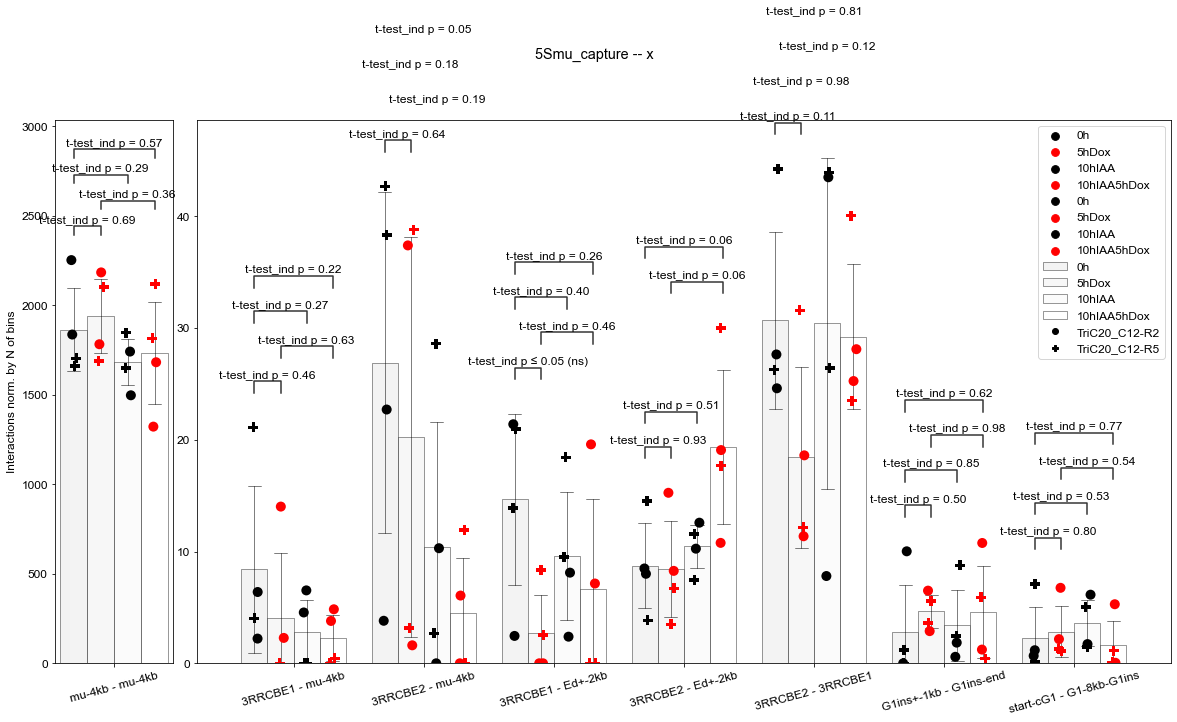

In [8]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 0.5


fig = plt.figure(figsize=(20,10))
maxInteraction = max(contactsums['pinteractions'])
maxInteraction = maxInteraction + maxInteraction/10

markerlist = ['o', 'P', 'X', '*']

ax1 = fig.add_subplot(1, 8, 1)
sns.barplot(data=contactsumsSelf, x='regioncomb', y='pinteractions', hue='treatment_time', ci='sd', color='white', linewidth=0.5, edgecolor='black', 
	errcolor='black', errwidth=0.5, capsize=0.1, alpha=0.8, ax=ax1)
markerCounter = 0
for (sampleName, group2) in contactsumsSelf.groupby('sample'):
	sns.stripplot(data=group2, x='regioncomb', y='pinteractions', hue='treatment_time', marker=markerlist[markerCounter], ax=ax1, dodge=True, size=10,
		palette=['black', 'red'])
	markerCounter +=1

boxlist = [] # list with pairs for statistical significance test
for reg in contactsumsSelf['regioncomb'].unique():
	boxlist = boxlist + [((reg, contactsumsSelf['treatment_time'].unique()[0]), (reg, contactsumsSelf['treatment_time'].unique()[1]))]
	boxlist = boxlist + [((reg, contactsumsSelf['treatment_time'].unique()[0]), (reg, contactsumsSelf['treatment_time'].unique()[2]))]
	boxlist = boxlist + [((reg, contactsumsSelf['treatment_time'].unique()[0]), (reg, contactsumsSelf['treatment_time'].unique()[3]))]
	boxlist = boxlist + [((reg, contactsumsSelf['treatment_time'].unique()[1]), (reg, contactsumsSelf['treatment_time'].unique()[3]))]
annot = Annotator(ax1, data=contactsumsSelf, x='regioncomb', y='pinteractions', hue='treatment_time', pairs=boxlist)
annot.configure(test='t-test_ind', text_format='simple', verbose=5, comparisons_correction="BH") #
annot.apply_and_annotate()

ax1.legend_.remove()
ax1.set_ylabel('Interactions norm. by N of bins')
ax1.set_xlabel('')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=15)



ax = fig.add_subplot(1, 8, (2, 8))
sns.barplot(data=contactsums, x='regioncomb', y='pinteractions', hue='treatment_time', ci='sd', color='white', linewidth=0.5, edgecolor='black', 
	errcolor='black', errwidth=0.5, capsize=0.1, alpha=0.8, ax=ax, order=region_order)
markerCounter = 0
for (sampleName, group2) in contactsums.groupby('sample'):
	sns.stripplot(data=group2, x='regioncomb', y='pinteractions', hue='treatment_time', marker=markerlist[markerCounter], ax=ax, dodge=True, size=10,
		palette=['black', 'red'], order=region_order)
	markerCounter +=1

boxlist = [] # list with pairs for statistical significance test
for reg in contactsums['regioncomb'].unique():
	boxlist = boxlist + [((reg, contactsums['treatment_time'].unique()[0]), (reg, contactsums['treatment_time'].unique()[1]))]
	boxlist = boxlist + [((reg, contactsums['treatment_time'].unique()[0]), (reg, contactsums['treatment_time'].unique()[2]))]
	boxlist = boxlist + [((reg, contactsums['treatment_time'].unique()[0]), (reg, contactsums['treatment_time'].unique()[3]))]
	boxlist = boxlist + [((reg, contactsums['treatment_time'].unique()[1]), (reg, contactsums['treatment_time'].unique()[3]))]
annot = Annotator(ax, data=contactsums, x='regioncomb', y='pinteractions', hue='treatment_time', pairs=boxlist, order=region_order)
annot.configure(test='t-test_ind', text_format='simple', verbose=5, comparisons_correction="BH") #
annot.apply_and_annotate()

f = lambda m,c: plt.plot([],[],marker=m, color=c, ls="none")[0]
handles, labels = ax.get_legend_handles_labels()
handles += [f(list(dict.fromkeys(markerlist))[i], "k") for i in range(len(dict.fromkeys(markerlist)))]
labels += list(contactsums['sample'].unique())
ax.legend(handles, labels)
ax.set_ylim(0, maxInteraction)
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
fig.suptitle(f"5Smu_capture -- x")

fig.savefig('../plots/TriC20/TriC20_human_RegOfInterest_markers_withG1-3pr.pdf')

mu-4kb - mu-4kb_0h v.s. mu-4kb - mu-4kb_5hDox: t-test independent samples with Bonferroni correction, P_val=6.910e-01 stat=-4.173e-01


3RRCBE2 - 3RRCBE1_0h v.s. 3RRCBE2 - 3RRCBE1_5hDox: t-test independent samples with Bonferroni correction, P_val=7.660e-01 stat=1.878e+00
3RRCBE2 - Ed+-2kb_0h v.s. 3RRCBE2 - Ed+-2kb_5hDox: t-test independent samples with Bonferroni correction, P_val=1.000e+00 stat=8.631e-02
3RRCBE1 - Ed+-2kb_0h v.s. 3RRCBE1 - Ed+-2kb_5hDox: t-test independent samples with Bonferroni correction, P_val=3.402e-01 stat=2.468e+00
3RRCBE1 - mu-4kb_0h v.s. 3RRCBE1 - mu-4kb_5hDox: t-test independent samples with Bonferroni correction, P_val=1.000e+00 stat=7.969e-01
3RRCBE2 - mu-4kb_0h v.s. 3RRCBE2 - mu-4kb_5hDox: t-test independent samples with Bonferroni correction, P_val=1.000e+00 stat=4.892e-01
start-G1ins - G1ins+-1kb_0h v.s. start-G1ins - G1ins+-1kb_5hDox: t-test independent samples with Bonferroni correction, P_val=1.661e-01 stat=-3.009e+00
G1ins+-1kb - G1ins-end_0h v.s. G1ins+-1kb - G1ins-end_5hDox: t-test independent samples with Bonferroni correction, P_val=1.246e-01 stat=-3.235e+00


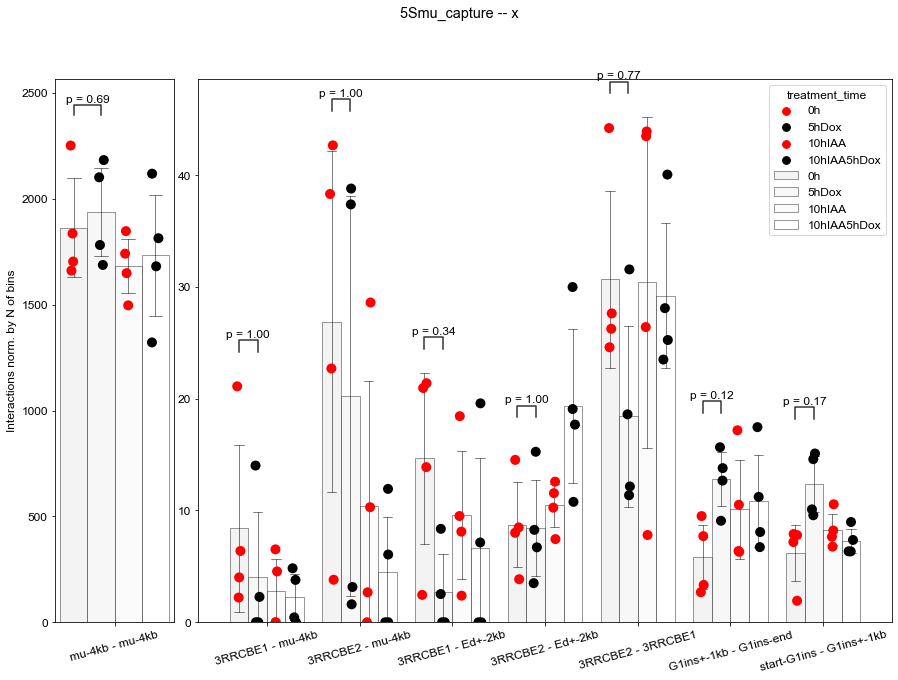

In [7]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 0.5


fig = plt.figure(figsize=(15,10))
maxInteraction = max(contactsums['pinteractions'])
maxInteraction = maxInteraction + maxInteraction/10

markerlist = ['o', 'P', 'X', '*']

ax1 = fig.add_subplot(1, 6, 1)
sns.barplot(data=contactsumsSelf, x='regioncomb', y='pinteractions', hue='treatment_time', ci='sd', color='white', linewidth=0.5, edgecolor='black', 
	errcolor='black', errwidth=0.5, capsize=0.1, alpha=0.8, ax=ax1)
sns.stripplot(data=contactsumsSelf, x='regioncomb', y='pinteractions', hue='treatment_time', ax=ax1, dodge=True, size=10,
	palette=['red', 'black'])

boxlist = [] # list with pairs for statistical significance test
for reg in contactsumsSelf['regioncomb'].unique():
	boxlist = boxlist + [((reg, contactsumsSelf['treatment_time'].unique()[0]), (reg, contactsumsSelf['treatment_time'].unique()[1]))]
statannot.add_stat_annotation(ax1, data=contactsumsSelf, x='regioncomb', y='pinteractions', hue='treatment_time', box_pairs=boxlist, test='t-test_ind', text_format='simple', verbose=2)

ax1.legend_.remove()
ax1.set_ylabel('Interactions norm. by N of bins')
ax1.set_xlabel('')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=15)



ax = fig.add_subplot(1, 6, (2, 6))
sns.barplot(data=contactsums, x='regioncomb', y='pinteractions', hue='treatment_time', ci='sd', color='white', linewidth=0.5, edgecolor='black', 
	errcolor='black', errwidth=0.5, capsize=0.1, alpha=0.8, ax=ax, order=region_order)
sns.stripplot(data=contactsums, x='regioncomb', y='pinteractions', hue='treatment_time', ax=ax, dodge=True, size=10,
	palette=['red', 'black'], order=region_order)

boxlist = [] # list with pairs for statistical significance test
for reg in contactsums['regioncomb'].unique():
	boxlist = boxlist + [((reg, contactsums['treatment_time'].unique()[0]), (reg, contactsums['treatment_time'].unique()[1]))]
statannot.add_stat_annotation(ax, data=contactsums, x='regioncomb', y='pinteractions', hue='treatment_time', box_pairs=boxlist, order=region_order, test='t-test_ind', text_format='simple', verbose=2)

ax.set_ylim(0, maxInteraction)
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
fig.suptitle(f"5Smu_capture -- x")

fig.savefig('../plots/TriC20/TriC20_human_RegOfInterest_withG1-3pr.pdf')